# 🌳 Stage 6 · Classifying · Random Forest

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DreamEmulator/rtu-computer-vision/blob/main/05_random-forests/random-forest.ipynb)

**Topic of the week:** Image Classification with Random Forests · **Lecture:** Tue 06.10 · **Startup question:** *Is the infusion running, stopped, or about to run dry?*

Everything so far was preparation. Now a model learns from the training frames and is graded only on the locked test set. For a medical product, overall accuracy isn't enough: missing a dry chamber (low recall on `low_fluid`) is a patient-safety issue.

| In the CI-pipeline | |
|---|---|
| Why? | [`README.md`](README.md) |
| How? — the 🎛️ tinker zone | [`classifying_random-forest/action.yaml`](classifying_random-forest/action.yaml) |
| What? — Step 0 to 3 | [`Todo_Classifying.md`](Todo_Classifying.md) |
| 🧪 Recipe — the model CI trains | [`classifying_random-forest/recipe.py`](classifying_random-forest/recipe.py) |
| 🧪 Sandboxes — one tree, the forest, the vote, the exam | [`classifying_random-forest/sandboxes/`](classifying_random-forest/sandboxes/) |

This notebook imports the **same functions** CI runs, with the values from your tinker zone. Explore here, then commit your choice to the tinker zone on a branch and let CI prove it.

In [1]:
# ⚙️ Setup — works locally, in Codespaces and in Colab (Colab already has every library we need)
import os, subprocess, sys
REPO = "DreamEmulator/rtu-computer-vision"  # filled in automatically in your own copy of the template
here = os.getcwd()
while not os.path.exists("run_pipeline.py") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")                      # notebooks live in the topic folders; the pipeline root is up
if not os.path.exists("run_pipeline.py"):   # Colab: fetch the repository first
    os.chdir(here)
    if not os.path.exists("repo"):
        subprocess.run(["git", "clone", "-q", f"https://github.com/{REPO}.git", "repo"], check=True)
    os.chdir("repo")
sys.path.insert(0, os.getcwd())

import cv2, json, numpy as np, matplotlib.pyplot as plt
from stages.common import load_images, to_luma
from stages.nb import prepare, run_stage, show
%matplotlib inline

In [2]:
cfg = prepare("extracting")
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
d = np.load("build/extracting/features.npz")
classes = [str(c) for c in d["classes"]]
X_train, X_test, y_train, y_test = d["X_train"], d["X_test"], d["y_train"], d["y_test"]
print(f"{len(y_train)} training frames (incl. augmented), {len(y_test)} test frames, {X_train.shape[1]} features")

✔ Stages up to 'extracting' ran with your tinker-zone values
540 training frames (incl. augmented), 90 test frames, 1924 features


## How many trees does a forest need?

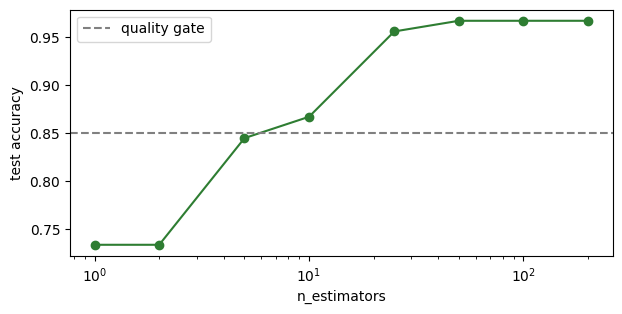

In [3]:
trees = [1, 2, 5, 10, 25, 50, 100, 200]
accs = [RandomForestClassifier(n, random_state=42, n_jobs=-1).fit(X_train, y_train).score(X_test, y_test) for n in trees]
plt.figure(figsize=(7, 3.2)); plt.semilogx(trees, accs, "o-", c="#2e7d32")
if cfg["random_forest"].get("gate_min_accuracy") is not None:
    plt.axhline(cfg["random_forest"]["gate_min_accuracy"], ls="--", c="gray", label="quality gate"); plt.legend()
plt.xlabel("n_estimators"); plt.ylabel("test accuracy"); plt.show()

## Precision, recall and the confusion matrix
**Precision:** when the model says *low_fluid*, how often is it right? **Recall:** of all real *low_fluid* frames, how many did it catch?

              precision    recall  f1-score   support

        drop      1.000     0.900     0.947        30
   low_fluid      1.000     1.000     1.000        30
     no_drop      0.909     1.000     0.952        30

    accuracy                          0.967        90
   macro avg      0.970     0.967     0.967        90
weighted avg      0.970     0.967     0.967        90



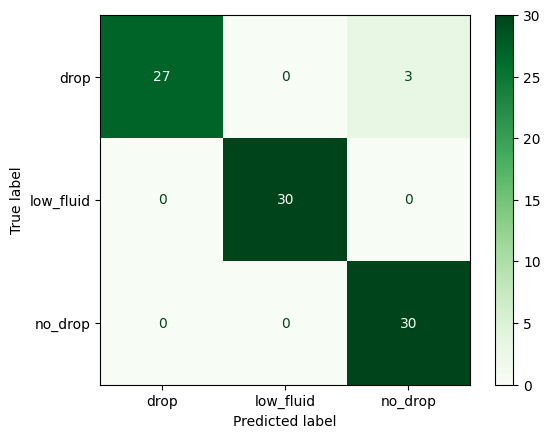

In [4]:
from stages.s6_classifying import build_model
rf = build_model({**cfg["random_forest"], "model": "random_forest"}, 42).fit(X_train, y_train)
pred = rf.predict(X_test)
print(classification_report(y_test, pred, target_names=classes, digits=3))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=classes, cmap="Greens"); plt.show()

## Where does the forest look?
Each HOG number belongs to a block of the frame. Adding up the forest's feature importances per block shows (roughly) which parts of the frame the decision depends on.

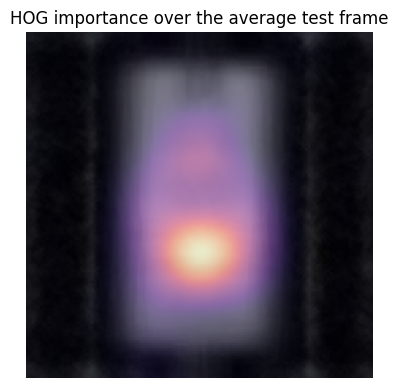

In [5]:
meta = json.load(open("build/extracting/meta.json")); h = cfg["extracting"]
dims = meta["feature_dims"]
if "hog" in dims:
    start = sum(n for name, n in list(dims.items())[:list(dims).index("hog")])
    H, W = d["I_test"].shape[1:3]
    ppc, cpb, ori = h["hog_pixels_per_cell"], h["hog_cells_per_block"], h["hog_orientations"]
    by, bx = H // ppc - cpb + 1, W // ppc - cpb + 1
    imp = rf.feature_importances_[start:start + dims["hog"]].reshape(by, bx, cpb, cpb, ori).sum(axis=(2, 3, 4))
    mean = d["I_test"].mean(0)
    mean = mean if mean.ndim == 2 else mean.mean(-1)
    plt.figure(figsize=(4.5, 4.5)); plt.imshow(mean, cmap="gray")
    plt.imshow(cv2.resize(imp.astype(np.float32), (W, H), interpolation=cv2.INTER_CUBIC), cmap="magma", alpha=0.55)
    plt.title("HOG importance over the average test frame"); plt.axis("off"); plt.show()
else:
    print("Add hog to features in the stage 5 tinker zone to see this map.")

## 🧪 Your turn
1. Which class does the forest confuse most? Open the preview in the `random_forest` artifact and look at the misclassified frames: what do they have in common?
2. `model: svm` and `model: knn`, then set `scaling: none` in stage 5. Why do these two care about scaling and the forest doesn't?
3. The gate `gate_min_class_recall` protects patients. Would you rather trade some precision for more recall on `low_fluid`? Try `class_weight: balanced`.
4. Send your snap through (`python run_pipeline.py --snap photo.jpg`) and read `build/random_forest/metrics.json`: how sure was the forest?

## 🚀 Ship your choice

1. Create a branch: `experiment/<what-you-change>`
2. Change **one** value in the 🎛️ TINKER ZONE of this topic's `action.yaml`
3. Push and open a pull request. The PR template asks for your hypothesis and result.
4. Compare the 🎤 Demo Day table of your PR with the one on `main`. Better? Merge. Not better? Close it and write down why — that's R&D too.